# Day 059 — Density-Based Clustering (DBSCAN & HDBSCAN)


In [2]:
# Setup & Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')



## 1. DBSCAN Algorithm — Density-Based Spatial Clustering


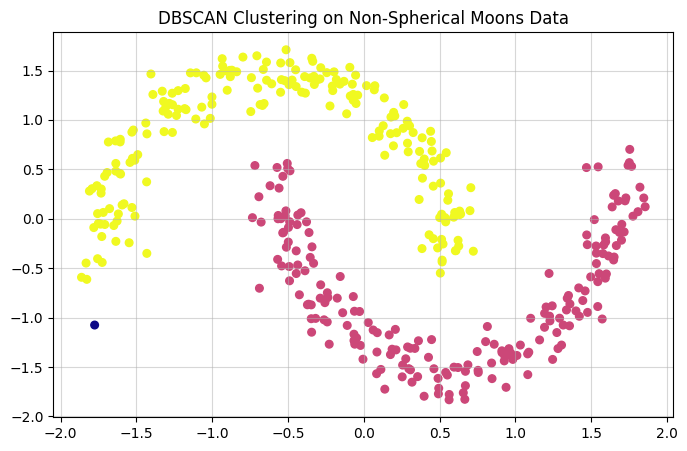

In [4]:
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

X, y = make_moons(n_samples=400, noise=0.08, random_state=42)
X_scaled = StandardScaler().fit_transform(X)

dbscan = DBSCAN(eps=0.25, min_samples=5)
labels = dbscan.fit_predict(X_scaled)

plt.figure(figsize=(8, 5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, cmap='plasma', s=30)
plt.title("DBSCAN Clustering on Non-Spherical Moons Data")
plt.grid(True, alpha=0.5)
plt.show()

## 2. Core Points, Border Points, Noise Points Classification


In [7]:
core_samples_mask = np.zeros_like(dbscan.labels_, dtype=bool)
core_samples_mask[dbscan.core_sample_indices_] = True

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print(f"Estimated Clusters: {n_clusters}")
print(f"Estimated Noise Points: {n_noise}")

Estimated Clusters: 2
Estimated Noise Points: 1


## 3. Hyperparameter Tuning — eps & min_samples


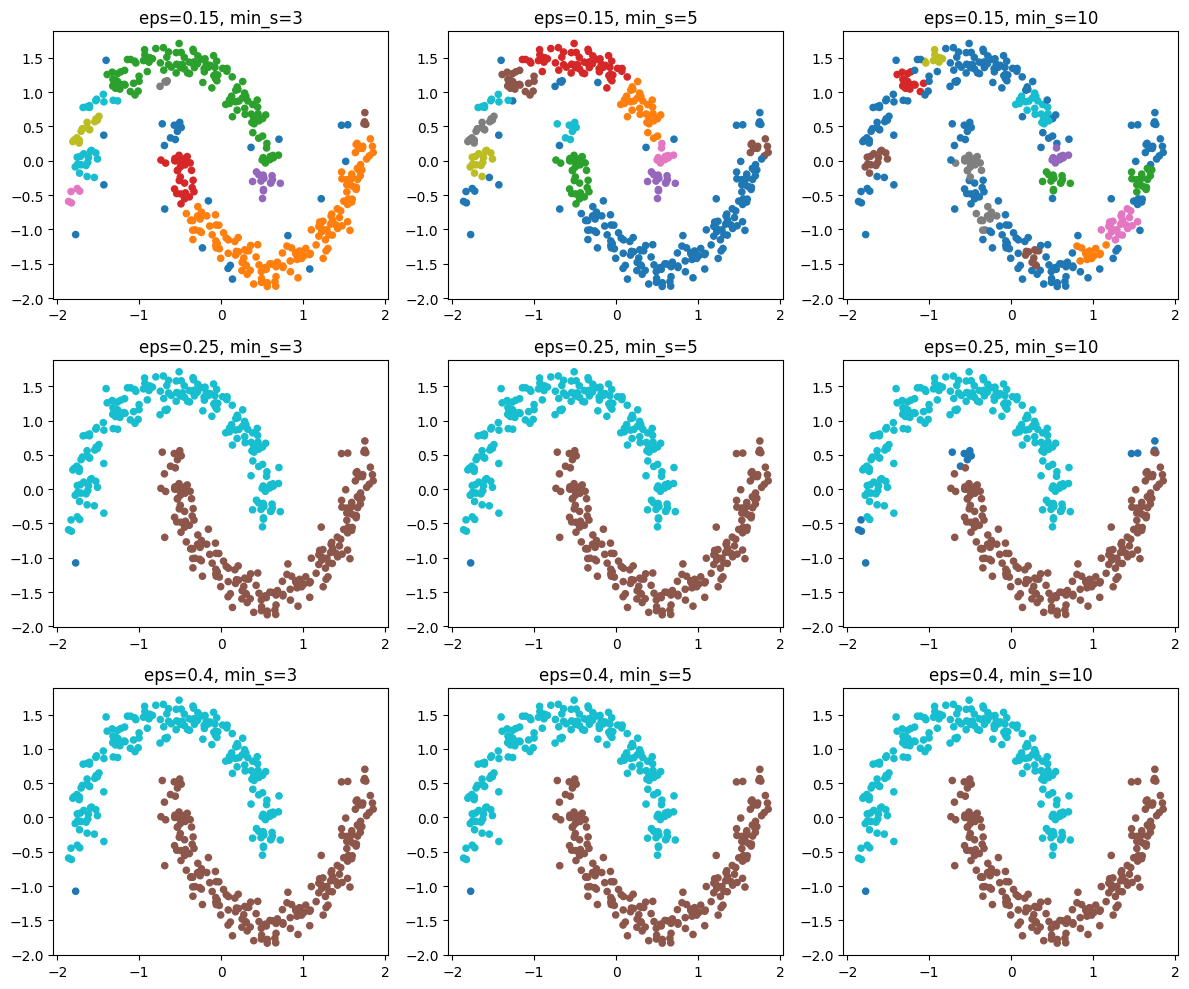

In [8]:
eps_values = [0.15, 0.25, 0.4]
min_samples_values = [3, 5, 10]

fig, axes = plt.subplots(3, 3, figsize=(12, 10))

for i, eps in enumerate(eps_values):
    for j, min_s in enumerate(min_samples_values):
        db = DBSCAN(eps=eps, min_samples=min_s).fit(X_scaled)
        ax = axes[i, j]
        ax.scatter(X_scaled[:, 0], X_scaled[:, 1], c=db.labels_, cmap='tab10', s=20)
        ax.set_title(f"eps={eps}, min_s={min_s}")

plt.tight_layout()
plt.show()

## 4. HDBSCAN & Non-Spherical Clusters


HDBSCAN fitted successfully!


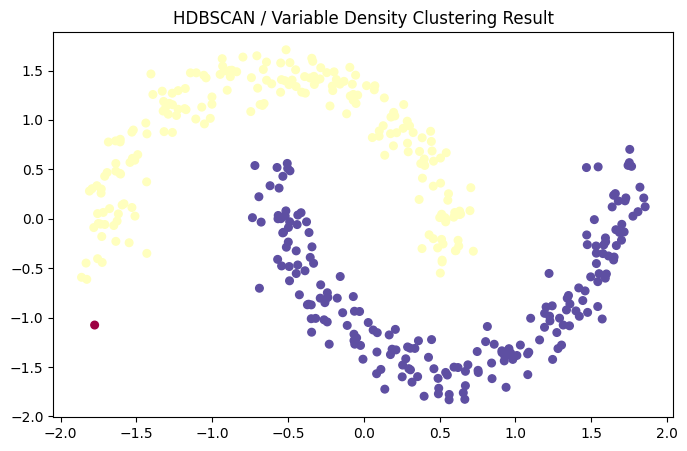

In [14]:
try:
    import hdbscan
    clusterer = hdbscan.HDBSCAN(min_cluster_size=10)
    hdb_labels = clusterer.fit_predict(X_scaled)
    print("HDBSCAN fitted successfully!")
except ImportError:
    print("HDBSCAN package not installed. Running standard DBSCAN fallback.")
    hdb_labels = DBSCAN(eps=0.2, min_samples=5).fit_predict(X_scaled)

plt.figure(figsize=(8, 5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=hdb_labels, cmap='Spectral', s=30)
plt.title("HDBSCAN / Variable Density Clustering Result")
plt.show()

In [13]:
!pip install hdbscan

   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   -------------------------------


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\sahil kumar\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip


## 5. Advantages over K-Means — Arbitrary Shapes & Noise Handling


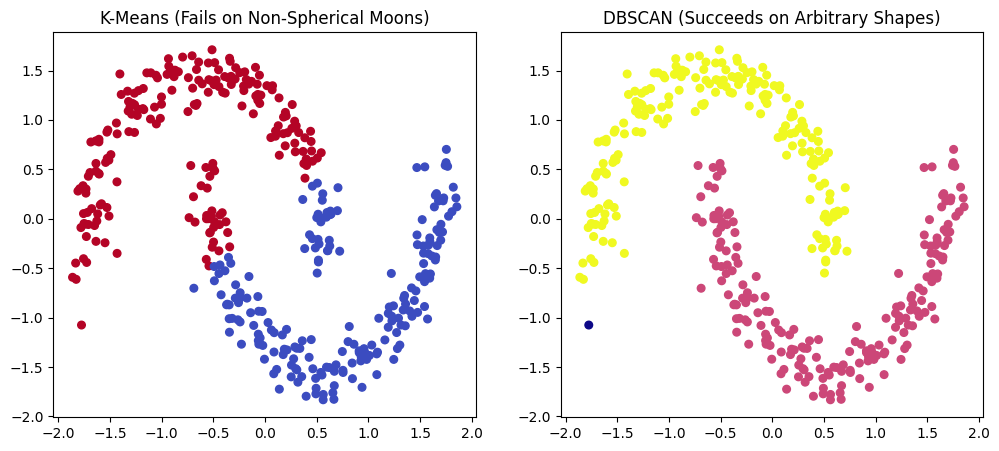

In [12]:
from sklearn.cluster import KMeans

km_labels = KMeans(n_clusters=2, random_state=42, n_init=10).fit_predict(X_scaled)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.scatter(X_scaled[:, 0], X_scaled[:, 1], c=km_labels, cmap='coolwarm', s=30)
ax1.set_title("K-Means (Fails on Non-Spherical Moons)")

ax2.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, cmap='plasma', s=30)
ax2.set_title("DBSCAN (Succeeds on Arbitrary Shapes)")

plt.show()